In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import mpltern
import pickle

import sys
from gpr_grad import RBFKernelFunction, GradientGP, CUR_deterministic

torch.set_default_dtype(torch.float64)

"""
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'mathtext.fontset': 'dejavusans',
    'mathtext.default': 'regular',
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'axes.linewidth': 0.6,
    'lines.linewidth': 1.2,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,
    'xtick.major.size': 3.0,
    'ytick.major.size': 3.0,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'savefig.dpi': 300,
    'figure.dpi': 150,
})
"""
import pandas as pd


def find_repo_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "HalideAqueousElectrolyte" / "NaClWater" / "data").is_dir():
            return candidate
    raise FileNotFoundError(
        "Cannot locate the extended_S0 checkout. Run this notebook from inside the clone.")


REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "HalideAqueousElectrolyte" / "NaClWater" / "data"


In [2]:
from scipy.interpolate import interp1d

ref_mu = pd.read_csv(DATA_DIR / "x_ion_mu_ex_debye.csv")

c_0 = ref_mu["c_NaCl_M"].iloc[0] / ref_mu["x_ion"].iloc[0]

x = ref_mu["x_ion"].to_numpy()
y = (ref_mu["c_NaCl_M"] / ref_mu["x_ion"] / c_0).to_numpy()
# Sort by x
idx = np.argsort(x)
x = x[idx]
y = y[idx]

# Piecewise-linear interpolating function
# This is c/x  / (c_0/x_0)
f_c = interp1d(
    x, y,
    kind="linear",
    bounds_error=False,
    fill_value="extrapolate"
)

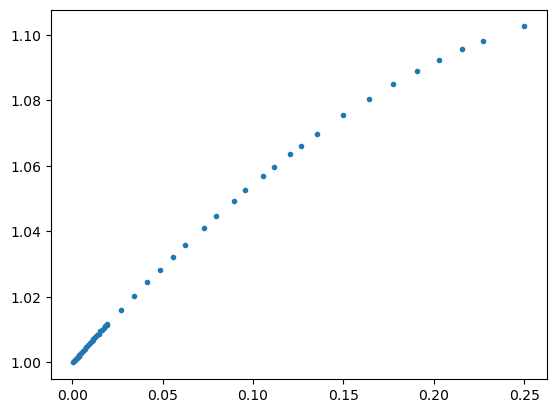

In [3]:
plt.plot(x, y, '.')

In [10]:
# constants
KB_IN_EV = 8.617e-5
T = 298.15
KB_T = KB_IN_EV * T
print(KB_T)

0.025691585499999996


In [5]:
# CSV_PATH = DATA_DIR / 'S0_NaClWater_individual_OZ_split0.csv'
CSV_PATH = DATA_DIR / 'S0_NaClWater_matrix_OZ_s_loss_split0.csv'
df = pd.read_csv(CSV_PATH)
df_selected = df.loc[df['kcut'] == 0.005]

In [6]:
#import s0_grad

#import importlib
#importlib.reload(s0_grad)

from szero import (
    prepare_gp_gradient_data,
    pure_component_anchor,
    atomic_fraction_to_xtilde,
)

In [7]:
column_map = {
    "x_O": "x_O",
    "x_Na": "x_Na",
    "x_Cl": "x_Cl",
    "S_OO": "S0_OO",
    "S_ONa": "S0_ONa",
    "S_OCl": "S0_OCl",
    "S_NaNa": "S0_NaNa",
    "S_NaCl": "S0_NaCl",
    "S_ClCl": "S0_ClCl",
}

independent_components = ["Na"]
components = ["O", "Na", "Cl"]


# selected multiple species: returns dict
gp_grad_data = prepare_gp_gradient_data(
    df_selected,
    independent_components=independent_components,
    column_map=column_map,
    components=components,
    species=["O", "Na", "Cl"], # for which species to return the chemical potential gradients. Can be a list or str
    temperature=298.15,
    excess=True,  # return the gradients for excess potential
    charges={"Na": 1, "Cl": -1, "O":0},
    as_torch=True,
)

In [8]:
mu_gp = {}
for species_now in components:
    X_g, G_g, grad_indices = gp_grad_data[species_now]
    
    X_f, Y_f = torch.tensor([[0.001]]), torch.tensor([[0.0]])
    
    X_star = torch.linspace(0.0, X_g.max(), 20)

    # -----------------------------
    # fit GP
    # -----------------------------
    # Trainable RBF length scales
    kernel = RBFKernelFunction(
        theta=torch.tensor([0.05]),
        trainable=False,
    )

    gp = GradientGP(
        kernel=kernel,
        sigma_f=0.0,
        sigma_g=0.1,
        trainable_sigma_f=False,
        trainable_sigma_g=False,
        jitter=1e-8,
    )

    gp.fit(X_f=X_f, 
           Y_f=Y_f, 
           X_g=X_g, 
           G_g=G_g, 
           grad_indices=grad_indices,)

    mean, cov = gp.predict(X_star[:, None])
    mu_gp[species_now] = mean

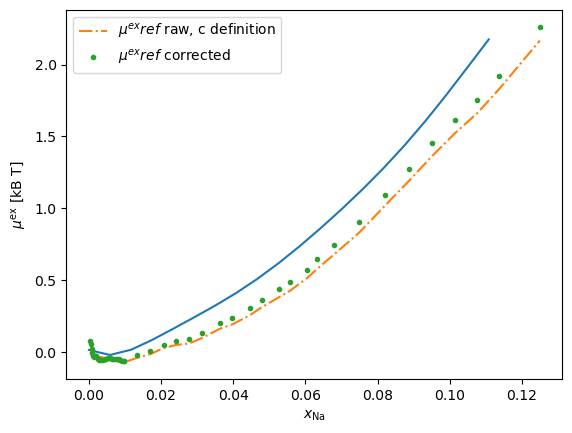

In [9]:
plt.plot(X_star, (mu_gp["Na"]/KB_T + mu_gp["Cl"]/KB_T)/2., '-')

plt.plot(ref_mu["x_ion"] / 2., ref_mu['mu_ex_kBT'] , '-.', label='$\mu^{ex} ref$ raw, c definition')
plt.plot(ref_mu["x_ion"] / 2., ref_mu['mu_ex_kBT'] +  np.log(f_c(ref_mu["x_ion"])), '.', label='$\mu^{ex} ref$ corrected')
plt.ylabel('$\mu^\mathrm{ex}$ [kB T]')
plt.xlabel('$x_\mathrm{Na}$')

plt.legend()